In [1]:
import matplotlib.pyplot as plt
import joblib as jlb
from collections import Counter
from sklearn.metrics import silhouette_score
import numpy as np
from Algorithm import CLARANS
from pyclustering.cluster.clarans import clarans
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca
from utils import clarans_fast_build,clarans_silhouette_analysis,clarans_davies_bouldin_analysis,clarans_Inertia_analysis

In [14]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy().sample(1000)
print(data.shape)
print(data.tail(1))

(1000, 3)
      balance  purchases  cash_advance
1423  0.94469    0.72033     -0.926725


In [15]:
k=3
n_nei=5
n_loop=5
model=clarans((np.array(data)).tolist(),k,n_nei,n_loop)
model.process()

In [30]:
clusters=model.get_clusters()
labels= np.full(len(data),-1)
for clusters_id,cluster in enumerate(clusters):
    for index in cluster :
        labels[index]=clusters_id
medoid=model.get_medoids()
medoids_points=np.array(data)[medoid]
data['cluster']=labels

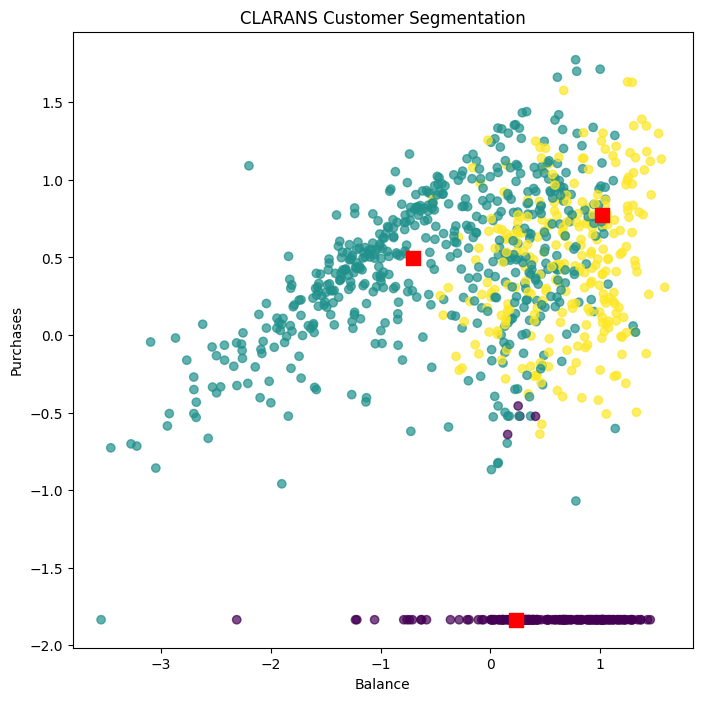

In [31]:
#hien thi model

plt.figure(figsize=(8,8))

plt.scatter(data['balance'],
            data['purchases'],
            c=data['cluster'], alpha=0.7)

plt.scatter(medoids_points[:, 0],
            medoids_points[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("CLARANS Customer Segmentation")

plt.show()

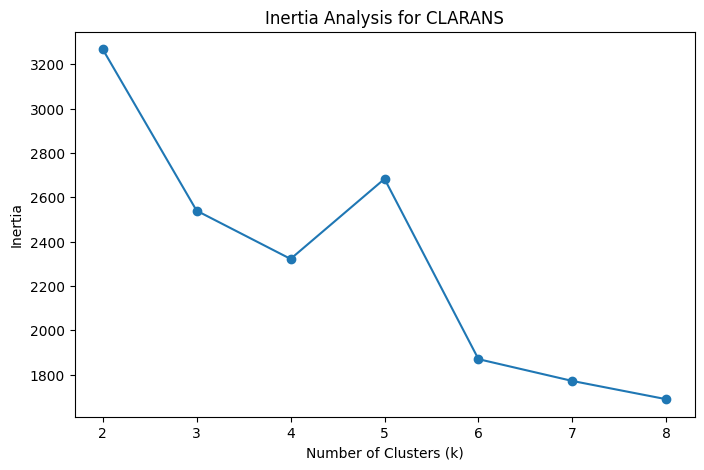

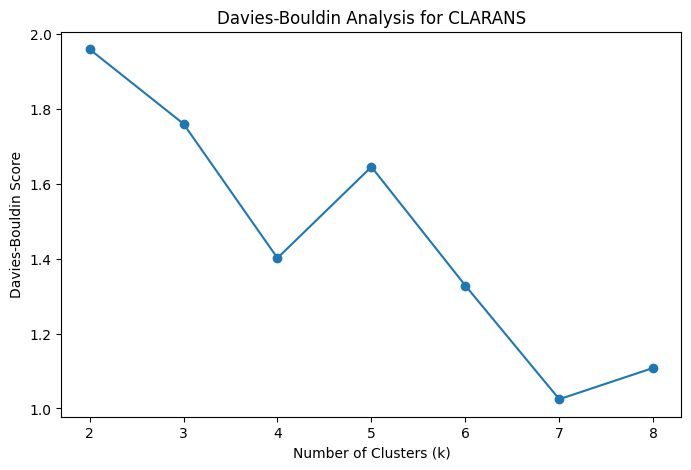

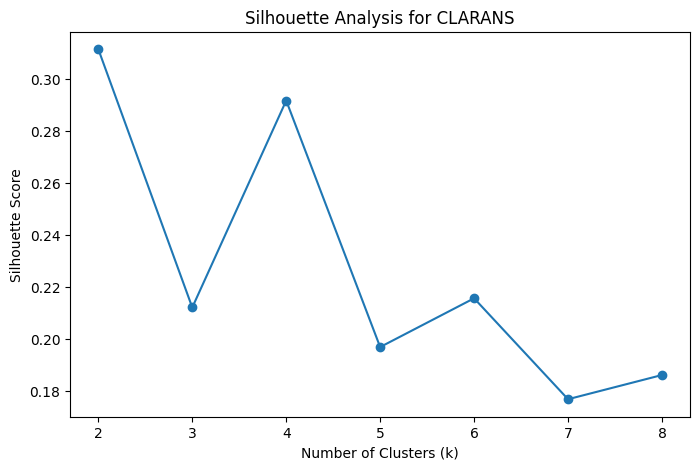

In [8]:
clarans_Inertia_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_davies_bouldin_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_silhouette_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

In [ ]:
#xay dung model clarans
k = 3
n_local=5
max_nei=5
Clarans_model = CLARANS(data, k, n_local, max_nei)
(ticks, result) = timedcall(Clarans_model.fit)
print(f"Time taken: {ticks:.4f} seconds")

Time taken: 0.0085 seconds


In [10]:
#lấy cluster và medoids
labels=Clarans_model.get_labels()
medoids = Clarans_model.get_medoids()

print("Labels:", labels)
print("Medoids:", medoids)

Labels: [0 1 1 ... 2 1 1]
Medoids: [[-2.3084604  -0.32607122 -0.92672452]
 [ 0.60157425  0.70125791 -0.92672452]
 [-0.36470957  0.96768907 -0.92672452]]


In [11]:
#gắn nhãn cluster đã có vào df
data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

    balance  purchases  cash_advance  cluster
0 -1.594479  -0.275098     -0.926725        0
1  0.746068  -1.836079      1.487937        1
2  0.611419   0.436726     -0.926725        1
3  0.009768  -0.868018     -0.926725        1
4  0.438191   0.622723     -0.926725        1

Kích thước clusters: Counter({np.int64(1): 1187, np.int64(2): 456, np.int64(0): 255})

2 clusters lớn nhất: [(np.int64(1), 1187), (np.int64(2), 456)]


In [12]:
#silhouette score
sil_score = silhouette_score(data.drop(columns=['cluster']), labels)
Clarans_model.sihouette_score_=sil_score
print(f'Silhouette Score: {Clarans_model.sihouette_score_:.4f}')

Silhouette Score: 0.2035


In [13]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [14]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

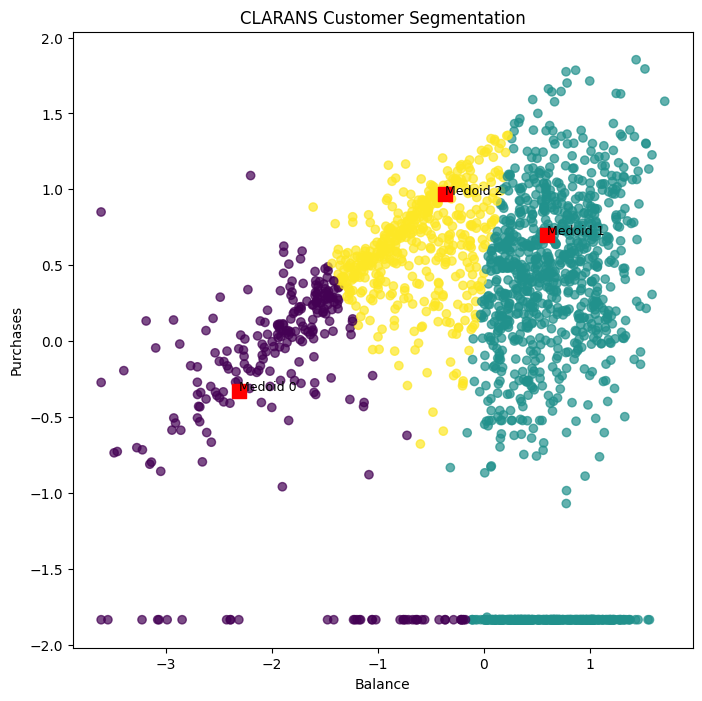

In [15]:
#hien thi model

plt.figure(figsize=(8,8))

plt.scatter(data['balance'],
            data['purchases'],
            c=data['cluster'], alpha=0.7)

for i, medoid in enumerate(medoids):
    plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("CLARANS Customer Segmentation")

plt.show()

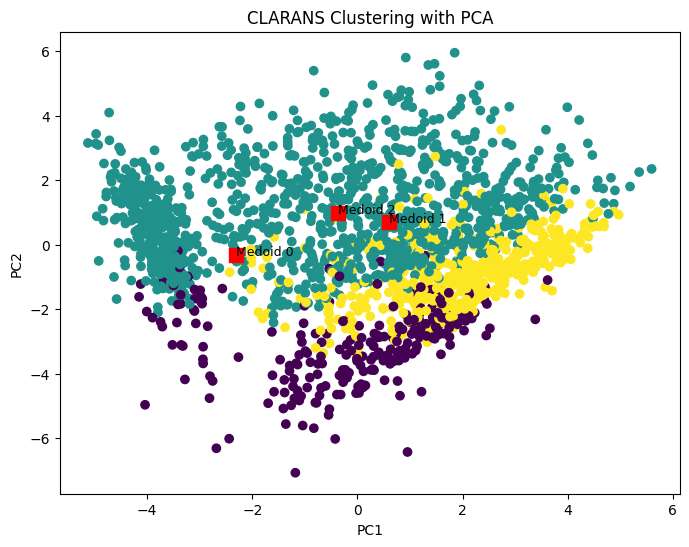

In [16]:

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=labels)
plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

for i, medoid in enumerate(medoids):
    plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()

Silhouette Score: 0.2775


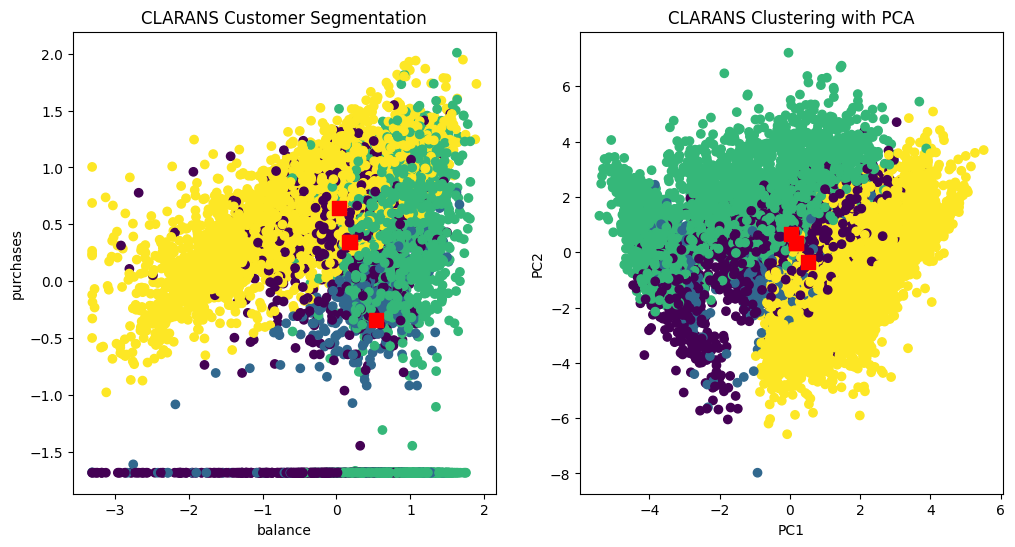

In [ ]:
k = 3
n_local=5
max_nei=5
features=[
 'balance',
 'purchases',
 'cash_advance'
]
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_fast_build(datafast,k,n_local,max_nei,'balance','purchases',data_pca)